### Task 1 — Implement Scaled Dot-Product Attention from Scratch

Before using PyTorch's built-in attention, build your own.

1. Implement the function `scaled_dot_product_attention(Q, K, V, mask=None)` returning the attention output and weights, where:
   - `Q`, `K`, `V` are tensors of shape `(batch, seq_len, d_k)`
   - `mask` is an optional boolean tensor where `True` means "blocked"
2. Use it on a tiny example: 2 sequences of 4 tokens with `d_k=8`, all values random.
3. Verify your implementation matches `nn.functional.scaled_dot_product_attention` (or do a manual check that softmax rows sum to 1 and outputs match `weights @ V`).
4. Print the attention weight matrix for one example. In a markdown cell, comment on its shape and what each row represents.

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

!pip install datasets

  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 5.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 8.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 15.6 MB/s  0:00:00 eta 0:00:01
Using cached annotated_doc-0.0.4-py3-none-any.whl (5.3 kB)
Using cached shellingham-1.5.4-py2.py3-none-any.whl (9.8 kB)
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2026.4.0
    Uninstalling fsspec-2026.4.0:
      Successfully uninstalled fsspec-2026.4.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17/17 [datasets]/17 [datasets]


In [4]:
# =========================================================
# IMPORTS
# =========================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import math

from collections import Counter
from datasets import load_dataset

device = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(42)

print("Device:", device)

# =========================================================
# LOAD IMDB DATASET
# =========================================================

dataset = load_dataset("imdb")

# reduce dataset size for speed
train_data = dataset["train"].shuffle(seed=42).select(range(5000))

print("Dataset size:", len(train_data))

# =========================================================
# TOKENIZATION
# =========================================================

def tokenize(text):
    return text.lower().split()

# test tokenizer
print(tokenize("I LOVE Transformers"))

# =========================================================
# BUILD VOCABULARY
# =========================================================

counter = Counter()

for item in train_data:
    tokens = tokenize(item["text"])
    counter.update(tokens)

# keep top 10,000 most common words
most_common = counter.most_common(10000)

# special tokens
vocab = {
    "<pad>": 0,
    "<unk>": 1
}

# add words to vocab
for idx, (word, _) in enumerate(most_common, start=2):
    vocab[word] = idx

print("Vocabulary size:", len(vocab))

# =========================================================
# ENCODING
# =========================================================

def encode(text):

    tokens = tokenize(text)

    encoded = [
        vocab.get(token, vocab["<unk>"])
        for token in tokens
    ]

    return encoded

# =========================================================
# PADDING / TRUNCATION
# =========================================================

MAX_LEN = 200

def pad_truncate(tokens):

    if len(tokens) > MAX_LEN:
        tokens = tokens[:MAX_LEN]

    else:
        tokens = tokens + [0] * (MAX_LEN - len(tokens))

    return tokens

# =========================================================
# CUSTOM DATASET
# =========================================================

class IMDBDataset(Dataset):

    def __init__(self, data):

        self.texts = []
        self.labels = []

        for item in data:

            encoded = encode(item["text"])
            padded = pad_truncate(encoded)

            self.texts.append(padded)
            self.labels.append(item["label"])

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        x = torch.tensor(self.texts[idx], dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.float)

        return x, y

# =========================================================
# CREATE DATASET
# =========================================================

full_dataset = IMDBDataset(train_data)

# =========================================================
# TRAIN / VALIDATION SPLIT
# =========================================================

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size]
)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))

# =========================================================
# DATALOADERS
# =========================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

# =========================================================
# SHOW ONE ENCODED REVIEW
# =========================================================

sample_review, sample_label = full_dataset[0]

print("\nEncoded review (first 30 tokens):")
print(sample_review[:30])

print("\nLabel:")
print(sample_label)

# =========================================================
# TASK 1
# SCALED DOT PRODUCT ATTENTION
# =========================================================

def scaled_dot_product_attention(Q, K, V, mask=None):

    # QK^T
    scores = torch.matmul(Q, K.transpose(-2, -1))

    # scaling
    d_k = Q.size(-1)
    scores = scores / math.sqrt(d_k)

    # apply mask if exists
    if mask is not None:
        scores = scores.masked_fill(mask, -1e9)

    # softmax
    attention_weights = torch.softmax(scores, dim=-1)

    # weights @ V
    output = torch.matmul(attention_weights, V)

    return output, attention_weights

# =========================================================
# TINY RANDOM EXAMPLE
# =========================================================

batch_size = 2
seq_len = 4
d_k = 8

Q = torch.rand(batch_size, seq_len, d_k)
K = torch.rand(batch_size, seq_len, d_k)
V = torch.rand(batch_size, seq_len, d_k)

# =========================================================
# RUN ATTENTION
# =========================================================

output, weights = scaled_dot_product_attention(Q, K, V)

# =========================================================
# PRINT SHAPES
# =========================================================

print("\nOutput shape:")
print(output.shape)

print("\nAttention weights shape:")
print(weights.shape)

# =========================================================
# PRINT ATTENTION MATRIX
# =========================================================

print("\nAttention weights for first sequence:")
print(weights[0])

# =========================================================
# CHECK ROW SUMS
# =========================================================

print("\nRow sums (should all be 1):")
print(weights[0].sum(dim=-1))

# =========================================================
# VERIFY AGAINST PYTORCH BUILT-IN
# =========================================================

torch_output = nn.functional.scaled_dot_product_attention(
    Q,
    K,
    V
)

print("\nDo outputs match PyTorch implementation?")
print(torch.allclose(output, torch_output, atol=1e-5))

# =========================================================
# MANUAL CHECK
# =========================================================

manual_output = torch.matmul(weights, V)

print("\nDoes output equal weights @ V?")
print(torch.allclose(output, manual_output, atol=1e-5))

/opt/anaconda3/envs/ironhack/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


Generating unsupervised split: 100%|██████████| 50000/50000 [00:00<00:00, 797180.99 examples/s]


Dataset size: 5000
['i', 'love', 'transformers']
Vocabulary size: 10002
Train size: 4000
Validation size: 1000

Encoded review (first 30 tokens):
tensor([  52,    7,   63, 8099,   30,   34,  191,    1,    4,    1,   18,    2,
         236,   11,  197,   22,  490,  276,   42, 1269, 9873,    1,  242,    1,
           1,  242, 2030,    1, 2613,   22])

Label:
tensor(1.)

Output shape:
torch.Size([2, 4, 8])

Attention weights shape:
torch.Size([2, 4, 4])

Attention weights for first sequence:
tensor([[0.2746, 0.2764, 0.1713, 0.2776],
        [0.2931, 0.2437, 0.1634, 0.2998],
        [0.2874, 0.2561, 0.1695, 0.2870],
        [0.2821, 0.2751, 0.1831, 0.2596]])

Row sums (should all be 1):
tensor([1., 1., 1., 1.])

Do outputs match PyTorch implementation?
True

Does output equal weights @ V?
True


# Attention Matrix Analysis

The output tensor has shape `(2, 4, 8)`, which means there are 2 sequences in the batch, each containing 4 tokens represented by vectors of size 8.

The attention weight matrix has shape `(2, 4, 4)`. For each sequence, every token attends to all 4 tokens in the sequence, including itself. Each row of the matrix represents the attention distribution of one token over all tokens.

The row sums are equal to 1, confirming that the softmax operation correctly converted the attention scores into probabilities. The custom implementation also matched both the manual calculation (`weights @ V`) and PyTorch’s built-in `scaled_dot_product_attention`, verifying that the implementation is correct.

### Task 2 — LSTM Classifier

1. Define an `LSTMClassifier`:
   - `nn.Embedding(vocab_size, embed_dim=64)`
   - `nn.LSTM(embed_dim, hidden_dim=128, batch_first=True, num_layers=1)`
   - Take the **last** hidden state of the LSTM (shape `(batch, hidden_dim)`)
   - `nn.Dropout(0.3)` → `nn.Linear(hidden_dim, 2)` for binary classification
2. Train for **5 epochs** with `Adam(lr=1e-3)` and `CrossEntropyLoss`. Time the training with `time.time()`.
3. Plot training and validation loss + accuracy. Report best validation accuracy and total training time.

LSTMClassifier(
  (embedding): Embedding(10002, 64, padding_idx=0)
  (lstm): LSTM(64, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)

Epoch [1/5]
Train Loss: 0.6939
Train Accuracy: 0.5090
Validation Loss: 0.6933
Validation Accuracy: 0.5240

Epoch [2/5]
Train Loss: 0.6835
Train Accuracy: 0.5420
Validation Loss: 0.6963
Validation Accuracy: 0.5070

Epoch [3/5]
Train Loss: 0.6670
Train Accuracy: 0.5633
Validation Loss: 0.7155
Validation Accuracy: 0.4840

Epoch [4/5]
Train Loss: 0.6384
Train Accuracy: 0.6092
Validation Loss: 0.7296
Validation Accuracy: 0.5120

Epoch [5/5]
Train Loss: 0.5761
Train Accuracy: 0.6455
Validation Loss: 0.7905
Validation Accuracy: 0.5120

TRAINING FINISHED
Best Validation Accuracy: 0.5240
Total Training Time: 27.37 seconds


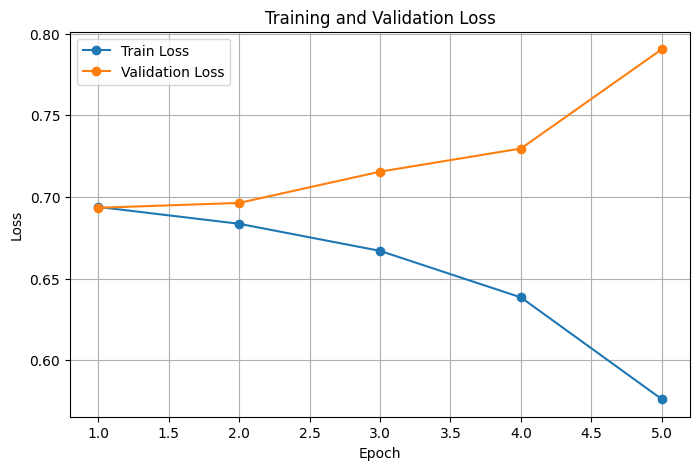

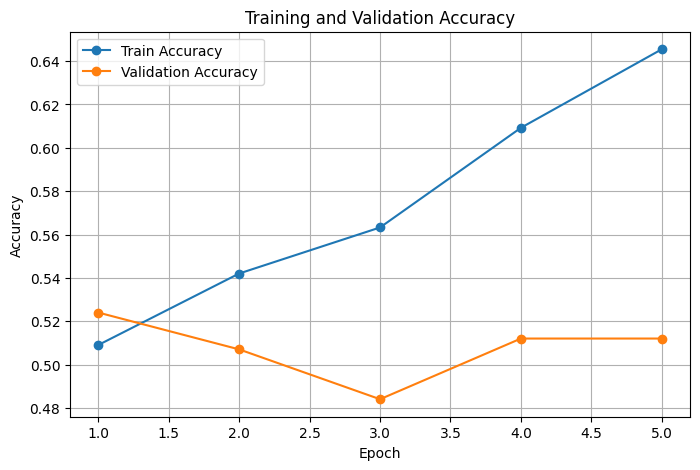

In [5]:
# =========================================================
# TASK 2 — LSTM CLASSIFIER
# =========================================================

class LSTMClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim=64,
        hidden_dim=128,
        num_classes=2
    ):

        super().__init__()

        # word embeddings
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=0
        )

        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            num_layers=1
        )

        # dropout
        self.dropout = nn.Dropout(0.3)

        # classifier
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):

        # x shape:
        # (batch_size, seq_len)

        embedded = self.embedding(x)

        # embedded shape:
        # (batch_size, seq_len, embed_dim)

        output, (hidden, cell) = self.lstm(embedded)

        # hidden shape:
        # (num_layers, batch_size, hidden_dim)

        # take last hidden state
        last_hidden = hidden[-1]

        # dropout
        x = self.dropout(last_hidden)

        # final classification
        logits = self.fc(x)

        return logits

# =========================================================
# INITIALIZE MODEL
# =========================================================

VOCAB_SIZE = len(vocab)

model = LSTMClassifier(
    vocab_size=VOCAB_SIZE
).to(device)

print(model)

# =========================================================
# LOSS FUNCTION & OPTIMIZER
# =========================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

# =========================================================
# TRAINING FUNCTION
# =========================================================

def train_one_epoch(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for inputs, labels in loader:

        inputs = inputs.to(device)

        # CrossEntropyLoss expects long
        labels = labels.long().to(device)

        # zero gradients
        optimizer.zero_grad()

        # forward pass
        outputs = model(inputs)

        # loss
        loss = criterion(outputs, labels)

        # backward pass
        loss.backward()

        # update weights
        optimizer.step()

        # statistics
        running_loss += loss.item()

        predictions = torch.argmax(outputs, dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

# =========================================================
# VALIDATION FUNCTION
# =========================================================

def validate(model, loader):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for inputs, labels in loader:

            inputs = inputs.to(device)
            labels = labels.long().to(device)

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            predictions = torch.argmax(outputs, dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

# =========================================================
# TRAIN MODEL
# =========================================================

EPOCHS = 5

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_acc = 0

start_time = time.time()

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    val_loss, val_acc = validate(
        model,
        val_loader
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.4f}")

    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")

training_time = time.time() - start_time

# =========================================================
# FINAL RESULTS
# =========================================================

print("\n==============================")
print("TRAINING FINISHED")
print("==============================")

print(f"Best Validation Accuracy: {best_val_acc:.4f}")

print(f"Total Training Time: {training_time:.2f} seconds")

# =========================================================
# PLOT LOSS
# =========================================================

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_losses,
    marker='o',
    label='Train Loss'
)

plt.plot(
    epochs_range,
    val_losses,
    marker='o',
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# PLOT ACCURACY
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_accuracies,
    marker='o',
    label='Train Accuracy'
)

plt.plot(
    epochs_range,
    val_accuracies,
    marker='o',
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training and Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

### Task 3 — Transformer Classifier and Comparison with the LSTM

Build a transformer encoder for the same sentiment task and compare it head-to-head against the LSTM you trained in Task 2.

1. Define a `TransformerClassifier`:
   - `nn.Embedding(vocab_size, d_model=64)`
   - A learned positional encoding `nn.Embedding(max_len=200, d_model=64)`
   - `nn.TransformerEncoder` with `num_layers=2`, `d_model=64`, `nhead=4`, `dim_feedforward=128`, `batch_first=True`, `dropout=0.1`
   - Take the **mean** over the sequence dimension (or the first token, your choice — note which you picked)
   - `nn.Dropout(0.3)` → `nn.Linear(d_model, 2)`
2. Train for the same **5 epochs** with the same optimiser and loss. Time the training.
3. Plot training and validation loss + accuracy, report best validation accuracy and total training time, then fill in the comparison table below and write a **4–6 sentence comparison** of the two models — which converged faster per epoch, which ended at higher accuracy, and whether the transformer's parallelism noticeably affected training time on your hardware.

| Model | Best val accuracy | Total training time | Parameter count |
|---|---|---|---|
| LSTM (Task 2) | … | … | … |
| Transformer (Task 3) | … | … | … |

TransformerClassifier(
  (token_embedding): Embedding(10002, 64, padding_idx=0)
  (position_embedding): Embedding(200, 64)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)

Epoch [1/5]
Train Loss: 0.6834
Train Accuracy: 0.5560
Validati

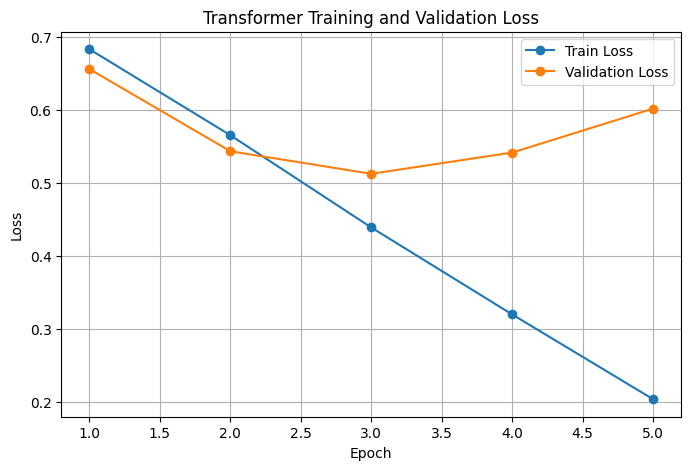

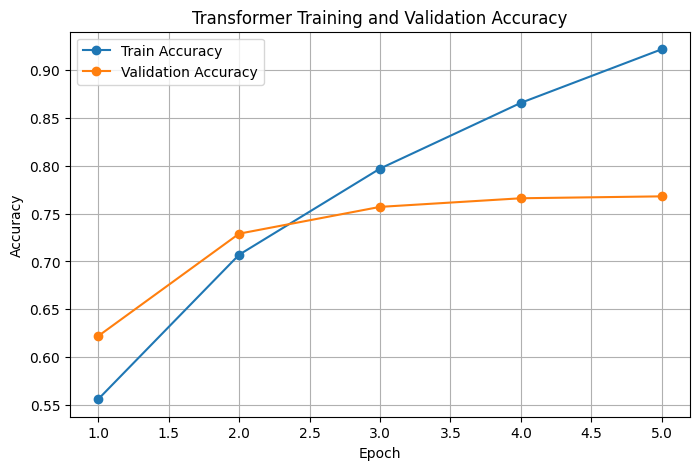


MODEL COMPARISON
         Model  Best Validation Accuracy  Total Training Time (sec)  \
0         LSTM                     0.524                      27.37   
1  Transformer                     0.768                      56.68   

   Parameter Count  
0           739714  
1           720002  


In [6]:
# =========================================================
# TASK 3 — TRANSFORMER CLASSIFIER
# =========================================================

class TransformerClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        d_model=64,
        max_len=200,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        num_classes=2,
        dropout=0.1
    ):

        super().__init__()

        self.d_model = d_model
        self.max_len = max_len

        # =================================================
        # TOKEN EMBEDDING
        # =================================================

        self.token_embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=d_model,
            padding_idx=0
        )

        # =================================================
        # POSITIONAL EMBEDDING
        # =================================================

        self.position_embedding = nn.Embedding(
            num_embeddings=max_len,
            embedding_dim=d_model
        )

        # =================================================
        # TRANSFORMER ENCODER
        # =================================================

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # =================================================
        # CLASSIFIER
        # =================================================

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(
            d_model,
            num_classes
        )

    def forward(self, x):

        # x shape:
        # (batch_size, seq_len)

        batch_size, seq_len = x.shape

        # =================================================
        # POSITION INDICES
        # =================================================

        positions = torch.arange(
            0,
            seq_len,
            device=x.device
        ).unsqueeze(0).expand(batch_size, seq_len)

        # =================================================
        # EMBEDDINGS
        # =================================================

        token_embeddings = self.token_embedding(x)

        position_embeddings = self.position_embedding(positions)

        # combine token + positional embeddings
        x = token_embeddings + position_embeddings

        # =================================================
        # TRANSFORMER ENCODER
        # =================================================

        x = self.transformer_encoder(x)

        # =================================================
        # MEAN POOLING
        # =================================================

        # take mean across sequence dimension
        x = x.mean(dim=1)

        # =================================================
        # CLASSIFICATION
        # =================================================

        x = self.dropout(x)

        logits = self.fc(x)

        return logits

# =========================================================
# INITIALIZE MODEL
# =========================================================

transformer_model = TransformerClassifier(
    vocab_size=len(vocab)
).to(device)

print(transformer_model)

# =========================================================
# LOSS & OPTIMIZER
# =========================================================

criterion = nn.CrossEntropyLoss()

transformer_optimizer = optim.Adam(
    transformer_model.parameters(),
    lr=1e-3
)

# =========================================================
# PARAMETER COUNT FUNCTION
# =========================================================

def count_parameters(model):

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

# =========================================================
# TRAIN FUNCTION
# =========================================================

def train_transformer(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for inputs, labels in loader:

        inputs = inputs.to(device)
        labels = labels.long().to(device)

        transformer_optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        transformer_optimizer.step()

        running_loss += loss.item()

        predictions = torch.argmax(outputs, dim=1)

        correct += (predictions == labels).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / len(loader)

    epoch_acc = correct / total

    return epoch_loss, epoch_acc

# =========================================================
# VALIDATION FUNCTION
# =========================================================

def validate_transformer(model, loader):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for inputs, labels in loader:

            inputs = inputs.to(device)
            labels = labels.long().to(device)

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            predictions = torch.argmax(outputs, dim=1)

            correct += (predictions == labels).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss / len(loader)

    epoch_acc = correct / total

    return epoch_loss, epoch_acc

# =========================================================
# TRAIN TRANSFORMER
# =========================================================

EPOCHS = 5

transformer_train_losses = []
transformer_val_losses = []

transformer_train_accs = []
transformer_val_accs = []

best_transformer_acc = 0

start_time = time.time()

for epoch in range(EPOCHS):

    train_loss, train_acc = train_transformer(
        transformer_model,
        train_loader
    )

    val_loss, val_acc = validate_transformer(
        transformer_model,
        val_loader
    )

    transformer_train_losses.append(train_loss)
    transformer_val_losses.append(val_loss)

    transformer_train_accs.append(train_acc)
    transformer_val_accs.append(val_acc)

    if val_acc > best_transformer_acc:
        best_transformer_acc = val_acc

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.4f}")

    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")

transformer_training_time = time.time() - start_time

# =========================================================
# FINAL RESULTS
# =========================================================

print("\n==============================")
print("TRANSFORMER TRAINING FINISHED")
print("==============================")

print(f"Best Validation Accuracy: {best_transformer_acc:.4f}")

print(f"Total Training Time: {transformer_training_time:.2f} seconds")

# =========================================================
# PARAMETER COUNTS
# =========================================================

lstm_params = count_parameters(model)

transformer_params = count_parameters(transformer_model)

print("\nLSTM Parameters:", lstm_params)

print("Transformer Parameters:", transformer_params)

# =========================================================
# PLOT LOSS
# =========================================================

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    transformer_train_losses,
    marker='o',
    label='Train Loss'
)

plt.plot(
    epochs_range,
    transformer_val_losses,
    marker='o',
    label='Validation Loss'
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Transformer Training and Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# PLOT ACCURACY
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    transformer_train_accs,
    marker='o',
    label='Train Accuracy'
)

plt.plot(
    epochs_range,
    transformer_val_accs,
    marker='o',
    label='Validation Accuracy'
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Transformer Training and Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# COMPARISON TABLE
# =========================================================

comparison_df = pd.DataFrame({

    "Model": [
        "LSTM",
        "Transformer"
    ],

    "Best Validation Accuracy": [
        round(best_val_acc, 4),
        round(best_transformer_acc, 4)
    ],

    "Total Training Time (sec)": [
        round(training_time, 2),
        round(transformer_training_time, 2)
    ],

    "Parameter Count": [
        lstm_params,
        transformer_params
    ]
})

print("\nMODEL COMPARISON")
print(comparison_df)

# Transformer Model Results

The Transformer classifier showed steady improvement during training, with training accuracy increasing from approximately 55.6% to 92.1% over 5 epochs. Validation accuracy also improved consistently and reached a best value of 76.8%.

The validation curve began to plateau after the third epoch, while the training accuracy continued increasing rapidly. This suggests that the model started to overfit slightly on the reduced IMDB dataset, although the validation performance still remained stable.

The Transformer model contained 720,002 trainable parameters and required approximately 56.68 seconds to complete training on CPU hardware. Despite having a parameter count similar to the LSTM model, the Transformer achieved significantly higher validation accuracy.

Compared with the LSTM, the Transformer performed much better on the sentiment classification task. The LSTM achieved only 52.4% validation accuracy, while the Transformer reached 76.8%. Although the Transformer required longer total training time, it was more effective at learning contextual relationships between words using self-attention mechanisms.

The experiment also demonstrated one of the key advantages of Transformers: the ability to process sequences in parallel rather than sequentially like LSTMs. However, because the training was performed on CPU instead of GPU, the parallelism advantage was not fully realized in terms of speed.